In [437]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import truncnorm
import time
from IPython.display import clear_output
import pandas as pd

Parameters:
1. Number Of Agents
2. Number of levels? Departments? Company Structure
3. Base Game Payoffs
4. Base Productivity
5. Initial Conditions: Integrity, Trust


In [438]:
global T, fraction_corrupt, game

In [455]:
class Agent: 
    def __init__(self, id, level, integrity, trust, mutation):
        self.id = id
        self.level = level
        self.integrity = integrity
        self.trust = trust
        self.mutation = mutation
        self.utility = 0.0
        self.strategy = 0
        self.payoff = game
        self.results = {}
        self.bosses = []
        self.peers = []
        self.underlings = []
    

    def get_opponents(self, opponents): #gets lost of opponent of type leywarg (used for play_game function in update)

        if isinstance(opponents, str):
            if opponents == 'bosses':
                return self.bosses
            elif opponents == 'peers':
                return self.peers
            elif opponents == 'underlings':
                return self.underlings
            else: 
                raise KeyError('Opponent must = bosses, peers or underlings' )
        else:
            raise TypeError('Opponent must a string and = bosses, peers or underlings')    


    #game functions:
    # 
    # 
    # 
         
    def update_payoff(self): #transform game matrix into individual payoffs
        global game
        self.payoff[0][0] = game[0][0]*(self.integrity)
        self.payoff[0][1] = game[0][1]*(self.integrity)
        self.payoff[1][0] = game[1][0]*(1-self.trust)
        self.payoff[1][1] = game[1][1]*(1-self.trust)
        
        return self.payoff
    
    def expected_opponent_strategy(self, t, fraction_corrupt, opponent): #find expected opponent strategy (right now based on fraction cooperating and trus)

        #base expected strategy on fraction of corrupt agents in the population and trust
        if t > 0: expected_strategy = (1-fraction_corrupt[-1])*self.trust #maybe better equation for this
        else: expected_strategy = .5
        return expected_strategy    

    def pick_strategy(self, t, fraction_corrupt, opponent): #pick strategy to play in the game
        #get expected opp strategy
        expected_strategy = self.expected_opponent_strategy(t, fraction_corrupt, opponent)

        #update payoff matrix
        payoff_matrix = self.update_payoff()

        #get utilities for every payoff
        uCC = payoff_matrix[0][0]
        uCD = payoff_matrix[0][1]
        uDC = payoff_matrix[1][0]
        uDD = payoff_matrix[1][1]

        #handle mixed strategies
        indifference_guess = (uCD - uDD) / (uDC - uCC + uCD - uDD) #Above this weight the opponent could put on cooperate D > C

        # pick strategy
        s = 0
        biggest_row = []
        #add mutation chance (pick randomly)
        if np.random.rand() < self.mutation: # adds a random mutation/deviation from the "rational" strategy
            s = np.random.choice([0,1], p=[.5,.5])
        else: #pick pick strategy
            if uCC > uDC and uCD > uDD: #Check for dominant strategy (can make these stochastic or use different heuristic)
                s = 0
                return s
            elif uCC < uDC and uCD < uDD:
                s = 1
                return s
            elif expected_strategy > indifference_guess : #Check for best expectation (mixed strategy)
                s = 1
                return s
            else:
                s = 0
                return s
            
        
    #Dynamic variables
    #
    #
    #

    def d_trust(self, t):
        if t>0:
            last_round_strategies = self.results[t-1].values()
            opp_def = 0
            result_count = 0

            for result in last_round_strategies:
                opp_def += result[1]
                result_count += 1
            if result_count > 0:
                fraction_def = opp_def/result_count
        
                d_trust = .2*(np.tan(np.pi/2*(.5-fraction_def)))
                while np.absolute(d_trust + self.trust) < 1:
                    self.trust += d_trust
                    return
                
            

            
            
            
            
        


        

    
    



Option 1: generate agents with network -- I did this
Option 2: generate network then add agents
Option 3: generate agents then generate network

In [440]:
def generate_network(level_size, integrity_mean, trust_mean, mutation):
    G = nx.DiGraph()
    ceo = Agent(0, 'CEO', truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1), truncnorm.rvs(-1, 1, loc=trust_mean, scale=1), mutation)
    G.add_node(ceo.id, level=0, agent=ceo)
    nodes_this_level = [ceo.id]
    for level, size in enumerate(level_size):
        nodes_level = []
        for employee in range(size):
            id = len(G.nodes)
            this_level = level + 1
            integrity = truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1)
            trust = truncnorm.rvs(-1, 1, loc=trust_mean, scale=1)
            agent = Agent(id, this_level, integrity, trust, mutation)
            G.add_node(agent.id, level=this_level, agent=agent)
            nodes_level.append(agent)
            
            if this_level == 1:
                G.add_edge(0, agent.id)
                agent.bosses.append(ceo)
                ceo.underlings.append(agent)
            else:
                boss_id = np.random.choice([n for n, d in G.nodes(data=True) if d['level'] == this_level - 1])
                G.add_edge(boss_id, agent.id)
                agent.bosses.append(G.nodes[boss_id]['agent'])
                G.nodes[boss_id]['agent'].underlings.append(agent)
        nodes_this_level.append(nodes_level)
        for employee in nodes_this_level[-1]:
            for peer in nodes_this_level[-1]:
                if employee != peer:
                    G.add_edge(employee.id, peer.id)
                    G.add_edge(peer.id, employee.id)
                    employee.peers.append(peer)
                    peer.peers.append(employee)
    return G

In [441]:
def initialize(level_size, integrity_mean, trust_mean, mutation):
    global game
    #prisoners dilemma matrix
    uCC = .75
    uCD = 0
    uDC = 1
    uDD = .5

    game = np.array([[uCC, uCD],
                     [uDC, uDD]])

    G = generate_network(level_size, integrity_mean, trust_mean, mutation)
    return G

In [442]:
def play_game(t, fraction_corrupt, node, opponents = str):

    opps = node.get_opponents(opponents)
    results = {}
    
    num_def = 0
    num_g = 0

    for opponent in opps:

        opp_strat = 0
        node_strat = 0

        opp_strat = opponent.pick_strategy(t, fraction_corrupt, node)
        node_strat = node.pick_strategy(t, fraction_corrupt, opponent)


        results[opponent.id] = (node_strat, opp_strat)

        num_def += opp_strat + node_strat

        num_g += 2

        
        
        


    return results, num_def, num_g

In [443]:
def update(G, t, fraction_corrupt):
    next_G = G
    results = []
    count_corrupt_t = 0
    games_count_t = 0
    print(G.nodes)
    for n in G.nodes:

        node = G.nodes[n]['agent']

        #Play game with peers
        r, num_defects, num_games = play_game(t, fraction_corrupt, node, 'peers')

        node.results[t] = r

        count_corrupt_t += num_defects

        results.append(r)

        games_count_t += num_games
    for n in G.nodes:

        node = G.nodes[n]['agent']

        node.d_trust(t)

    fraction_corrupt_t = count_corrupt_t/games_count_t
    return next_G, fraction_corrupt_t, results

In [444]:
def plot_network(G):
    pos = nx.kamada_kawai_layout(G)
    levels = np.array([G.nodes[n]['level'] for n in G.nodes])
    integrities = np.array([G.nodes[n]['agent'].integrity for n in G.nodes])
    trusts = np.array([G.nodes[n]['agent'].trust for n in G.nodes])
    sizes = 1800 / (levels + 1)
    plt.figure(figsize=(10, 7))
    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)
    #nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)
    nodes = nx.draw_networkx_nodes(G, pos, node_color=trusts, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)
    nx.draw_networkx_labels(G, pos, font_size=8)
    #plt.colorbar(nodes, label='Integrity')
    plt.colorbar(nodes, label='Trust')
    plt.axis('off')
    plt.show()

In [445]:
def observe(G, model_data):
    plot_network(G)

    plt.plot(model_data.fraction_corrupt)

In [446]:
def run(time_steps, level_size = [3, 9], integrity_mean=0, trust_mean=0, mutation=0):
    N = np.sum(level_size)
    G = initialize(level_size, integrity_mean, trust_mean, mutation)
    fraction_corrupt = []

    model_data = pd.DataFrame(columns=['time_step', 'fraction_corrupt', 'mean_trust', 'results'])

    for t in range(time_steps):
        G, fraction_corrupt_t, results = update(G, t, fraction_corrupt)

        trusts = []

        for n in G.nodes: 
            trusts.append(G.nodes[n]['agent'].trust)

        mean_trust = np.mean(trusts)

        row_data = {
            'time_step': t,
            'fraction_corrupt': fraction_corrupt_t,
            'mean_trust': mean_trust,
            'results': results
        }

        model_data = pd.concat([model_data, pd.DataFrame([row_data])], ignore_index=True)

        observe(G, model_data)
        fraction_corrupt.append(fraction_corrupt_t)

        clear_output(wait=True)
        time.sleep(.1)
    observe(G, model_data)
    return G, N, model_data

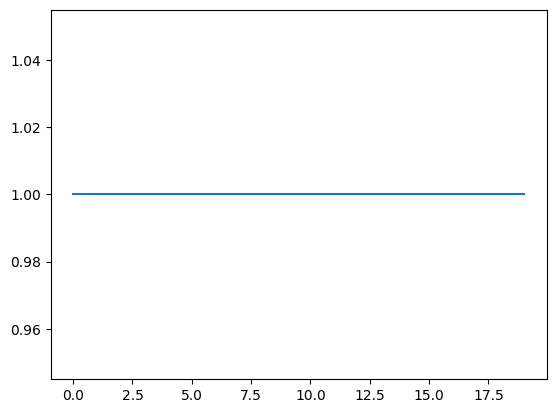

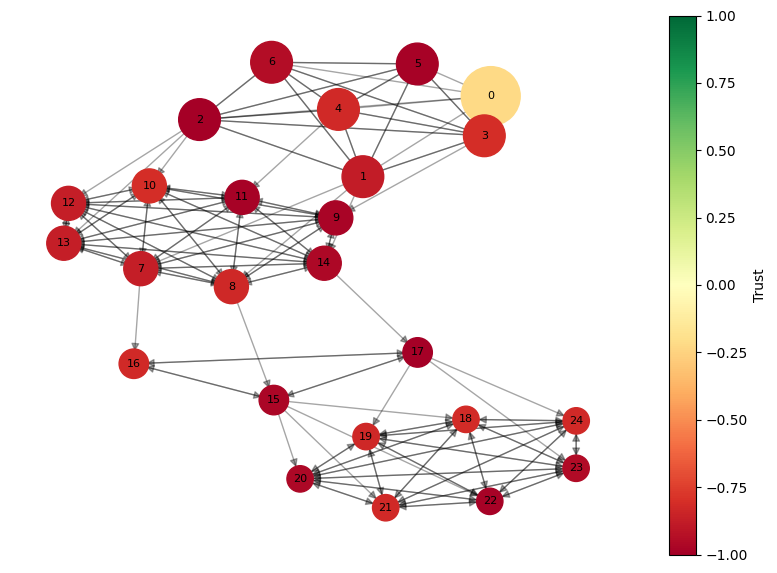

24


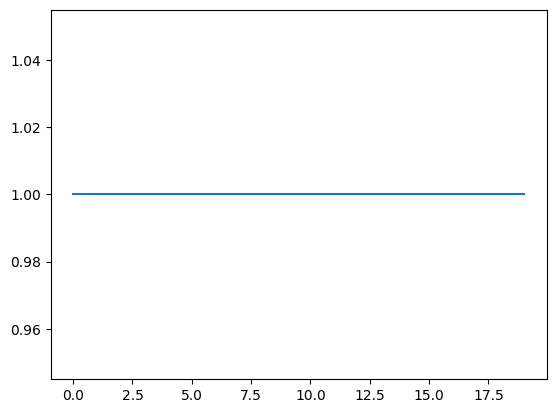

In [471]:
G, N, model_data = run(20, [6, 8, 3, 7], .5, .1)
print(N)

In [ ]:

display(model_data)



,time_step,fraction_corrupt,mean_trust,results
0,0,0.880597,0.054179,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
1,1,0.880597,-0.112915,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
2,2,0.880597,-0.264009,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
3,3,0.880597,-0.391103,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
4,4,0.880597,-0.502197,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
5,5,0.880597,-0.589291,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
6,6,0.880597,-0.663767,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
7,7,0.880597,-0.713004,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
8,8,0.880597,-0.746242,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."
9,9,0.880597,-0.763479,"[{}, {2: (1, 1), 3: (1, 1), 4: (1, 1), 5: (1, ..."


agents ascribe strategy to all underlying based on perceptions
--> ascribe strategy to peers based on perceptions
--> ascribe strategy to superiors based on perceptions
Strategy expected payoffs are based on integrity, trust, and perceptions of others' strategies
cooperate cooperate results outcome: highest productivity for company
pay of boss is based on productivity of underlings 

agents update trust based on: person they can see (connected too) with highest utility: if that person is cooperating, they increase trust, if that person is defecting, they decrease trust.

agents update integrity on longer time scale (add later)

perception of others' strategies based on: trust (and history of interactions with them (add later))